<a href="https://colab.research.google.com/github/aiman0642/saas-retention-intelligence/blob/main/08_risk_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 8 — Churn Probability & Risk Scoring

**Project:** SaaS Customer Retention Intelligence System

**Goal of this notebook:** Module 7 evaluated models on the *test split*
only. This notebook does something different and more operational: score
**every account** in the dataset with a churn probability and a
business-facing risk level, using the winning model (Logistic
Regression, per Module 7's verdict). This is the output a retention team
would actually look at — not a metric, a per-customer number.

**Assumes:** Modules 5, 6, and 7 have been run (needs
`account_view_engineered.csv`, the saved scaler, and
`logistic_regression.pkl`).

## 8.1 Mount Google Drive & Load Model, Scaler, and Full Account Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

PROJECT_DIR = "/content/drive/MyDrive/saas-retention-intelligence"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
MODELS_DIR = f"{PROJECT_DIR}/models"

account_view = pd.read_csv(f"{PROCESSED_DIR}/account_view_engineered.csv", parse_dates=["signup_date", "churn_date"])
X_train = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")  # only used to get the exact training column set/order
scaler = joblib.load(f"{MODELS_DIR}/scaler.pkl")
log_reg = joblib.load(f"{MODELS_DIR}/logistic_regression.pkl")

print(f"account_view: {account_view.shape}  (scoring ALL accounts, not just the test split)")
print(f"Training column count (target to match): {X_train.shape[1]}")

account_view: (500, 39)  (scoring ALL accounts, not just the test split)
Training column count (target to match): 41


## 8.2 Rebuild the Full Feature Matrix (Same Steps as Module 5)

Module 5 only saved the train/test *split* — for operational scoring we
need every account, including the ones that were in the training set.
This repeats Module 5's exact preprocessing (leakage-column drop,
encoding) on the *full* account table rather than a split, so every
account gets a score.

In [3]:
leakage_cols = ["churn_date"]
redundant_cols = ["tenure_bucket", "usage_bucket", "mrr_bucket", "plan_tier_sub", "last_activity_date"]

df = account_view.drop(columns=[c for c in leakage_cols + redundant_cols if c in account_view.columns])

id_cols = ["account_id", "account_name"]
account_ids = df["account_id"].copy()

df_model = df.drop(columns=[c for c in id_cols if c in df.columns])
df_model = df_model.drop(columns=["signup_date"], errors="ignore")

categorical_cols = [c for c in ["industry", "country", "plan_tier", "billing_frequency", "referral_source"]
                     if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

bool_cols = df_model.select_dtypes(include="bool").columns.tolist()
df_model[bool_cols] = df_model[bool_cols].astype(int)

y_true_full = df_model["churn_flag"]
X_full = df_model.drop(columns=["churn_flag"])

print(f"X_full shape before column alignment: {X_full.shape}")

X_full shape before column alignment: (500, 41)


## 8.3 Align Columns to Match Training Exactly

One-hot encoding the full dataset independently can, in principle,
produce slightly different columns than encoding the training split
alone (e.g. a rare category present in one but not the other). Reindex
to the exact training column set — any column the model expects but
that's missing here gets filled with 0; any extra column not seen
during training gets dropped. This is standard practice for scoring
pipelines and prevents a silent feature mismatch from reaching the model.

In [4]:
missing_in_full = set(X_train.columns) - set(X_full.columns)
extra_in_full = set(X_full.columns) - set(X_train.columns)
print(f"Columns in training but missing here (will fill with 0): {missing_in_full or 'none'}")
print(f"Columns here but not in training (will drop): {extra_in_full or 'none'}")

X_full = X_full.reindex(columns=X_train.columns, fill_value=0)
assert list(X_full.columns) == list(X_train.columns), "Column mismatch after alignment — do not proceed"
print(f"\nX_full aligned shape: {X_full.shape}  (matches training: {X_full.shape[1] == X_train.shape[1]})")

Columns in training but missing here (will fill with 0): none
Columns here but not in training (will drop): none

X_full aligned shape: (500, 41)  (matches training: True)


## 8.4 Scale and Predict Churn Probability

Logistic Regression needs scaled features (Module 4/5), using the
**already-fitted** scaler from training — never re-fit a scaler on
scoring data, that would let the scoring set's distribution leak into
the transformation.

In [5]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if X_train[c].nunique() > 2]

X_full_scaled = X_full.copy()
X_full_scaled[numeric_cols] = scaler.transform(X_full[numeric_cols])

churn_probability = log_reg.predict_proba(X_full_scaled)[:, 1]

account_view["churn_probability"] = churn_probability
print(account_view[["account_id", "churn_flag", "churn_probability"]].head(10))

  account_id  churn_flag  churn_probability
0   A-2e4581       False           0.336580
1   A-43a9e3        True           0.443463
2   A-0a282f       False           0.656807
3   A-1f0ac7       False           0.324267
4   A-ce550d        True           0.794607
5   A-1b9609       False           0.378717
6   A-a0ca4e       False           0.445952
7   A-e5d6ab       False           0.270939
8   A-7dacce        True           0.436473
9   A-10b8da        True           0.302459


## 8.5 Assign Risk Levels

Standard 3-tier bucketing from the project plan. These thresholds are a
**business choice**, not a statistical one — a retention team with more
outreach capacity might lower the "High" cutoff to flag more accounts
earlier; a team with less capacity might raise it to focus only on the
clearest cases. 30/70 is a reasonable starting default, documented here
so it's easy to tune later without touching the model itself.

risk_level
Low       107
Medium    335
High       58
Name: count, dtype: int64


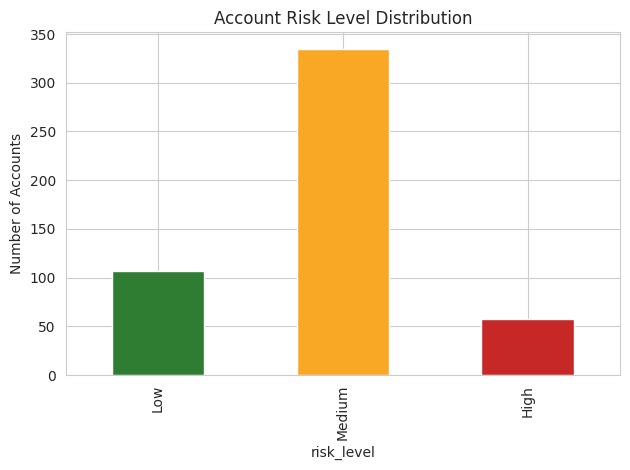

In [6]:
def assign_risk_level(prob):
    if prob < 0.30:
        return "Low"
    elif prob < 0.70:
        return "Medium"
    else:
        return "High"

account_view["risk_level"] = account_view["churn_probability"].apply(assign_risk_level)

risk_distribution = account_view["risk_level"].value_counts().reindex(["Low", "Medium", "High"])
print(risk_distribution)

ax = risk_distribution.plot(kind="bar", color=["#2E7D32", "#F9A825", "#C62828"])
ax.set_ylabel("Number of Accounts")
ax.set_title("Account Risk Level Distribution")
plt.tight_layout()
plt.show()

## 8.6 Sanity Check: Does Risk Level Track Actual Churn?

Before trusting these scores for anything downstream, confirm the risk
buckets actually separate real outcomes — accounts in "High" risk should
have a meaningfully higher actual churn rate than "Low" risk accounts.
Note this includes training-set accounts the model has already seen, so
treat this as a sanity check on ordering/calibration, not a substitute
for Module 7's held-out test metrics.

Actual churn rate by assigned risk level:
risk_level
Low       0.074766
Medium    0.214925
High      0.517241
Name: churn_flag, dtype: float64


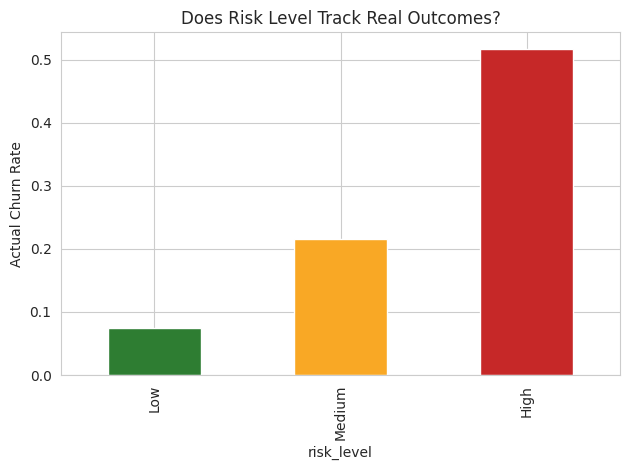

In [7]:
actual_churn_by_risk = account_view.groupby("risk_level")["churn_flag"].mean().reindex(["Low", "Medium", "High"])
print("Actual churn rate by assigned risk level:")
print(actual_churn_by_risk)

ax = actual_churn_by_risk.plot(kind="bar", color=["#2E7D32", "#F9A825", "#C62828"])
ax.set_ylabel("Actual Churn Rate")
ax.set_title("Does Risk Level Track Real Outcomes?")
plt.tight_layout()
plt.show()

## 8.7 Example: Individual Customer Risk Lookup

What Module 13's dashboard "Customer Risk" page will actually show —
pulling a few concrete examples here rather than only aggregate charts.

In [8]:
example_cols = ["account_id", "plan_tier", "mrr_amount", "tenure_days",
                 "churn_flag", "churn_probability", "risk_level"]

print("5 highest-risk accounts currently active (not yet churned):")
highest_risk_active = account_view[account_view["churn_flag"] == False].sort_values(
    "churn_probability", ascending=False
).head(5)
print(highest_risk_active[example_cols].to_string(index=False))

5 highest-risk accounts currently active (not yet churned):
account_id  plan_tier  mrr_amount  tenure_days  churn_flag  churn_probability risk_level
  A-432483        Pro        1519          694       False           0.928636       High
  A-b7724f      Basic         551          644       False           0.837046       High
  A-d792a6 Enterprise       12935          708       False           0.816664       High
  A-019782 Enterprise           0          622       False           0.809210       High
  A-b78bf8        Pro        1617           46       False           0.807053       High


## 8.8 Save Account-Level Risk Scores

This is the file Module 9 (SHAP), Module 10 (Revenue at Risk), and
Module 13 (Streamlit dashboard) all build on directly.

In [9]:
risk_scores = account_view[["account_id", "churn_flag", "churn_probability", "risk_level"]]
risk_scores.to_csv(f"{PROCESSED_DIR}/account_risk_scores.csv", index=False)

print(f"Saved account_risk_scores.csv ({risk_scores.shape[0]} accounts) to {PROCESSED_DIR}")

Saved account_risk_scores.csv (500 accounts) to /content/drive/MyDrive/saas-retention-intelligence/data/processed


## 8.9 Module 8 Summary

- Scored **every account** (not just the test split) with a churn
  probability using the Module 7-selected Logistic Regression model
- Rebuilt Module 5's exact preprocessing on the full dataset and
  explicitly aligned columns to the training set to avoid a silent
  feature mismatch
- Bucketed accounts into Low / Medium / High risk using documented,
  tunable thresholds (30% / 70%) rather than fixed, unexplained cutoffs
- Sanity-checked that risk level actually tracks real churn outcomes
  before trusting it downstream
- Saved `account_risk_scores.csv` for Module 9, 10, and the dashboard

**Next:** Module 9 — Explainable AI (SHAP)